In [3]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# Excel 데이터를 데이터프레임 변환 
df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')

# 첫 5행 출력
df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,NaN,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,NaN,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,NaN,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


In [4]:
# 누락값(NaN)을 앞 데이터로 채움 (엑셀 양식 병합 부분)
df = df.ffill()
df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,전국,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,전국,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,전국,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


In [5]:
# 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

In [6]:
# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시') 
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul = df_seoul.rename({'전입지별':'전입지'}, axis=1)
df_seoul = df_seoul.set_index('전입지')
df_seoul

# ^

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,2441242,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,28542,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
대구광역시,-,-,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
인천광역시,-,-,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
광주광역시,-,-,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932
대전광역시,-,-,-,-,-,-,-,-,-,-,...,13515,13632,13819,13900,14080,13440,13403,13453,12619,11815
울산광역시,-,-,-,-,-,-,-,-,-,-,...,5057,4845,4742,5188,5691,5542,6047,5950,5102,4260
세종특별자치시,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,2998,2851,6481,7550,5943,5813
경기도,130149,150313,93333,143234,149045,253705,202276,207722,237684,278411,...,412408,398282,410735,373771,354135,340801,332785,359337,370760,342433


<Axes: >

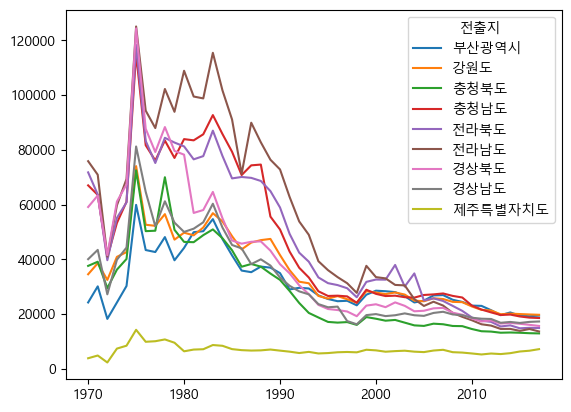

In [7]:
#  다른지역에서 서울로 이동하는 데이터
mask2 = (df['전출지별'] != '서울특별시') & (df['전입지별'] == '서울특별시') 
df_go_seoul = df[mask2]
df_go_seoul = df_go_seoul.drop(columns=['전입지별'])
df_go_seoul = df_go_seoul.rename(columns={'전출지별':'전출지'})
df_go_seoul = df_go_seoul.set_index('전출지')
df_go_seoul = df_go_seoul.drop(index=['전국'])

# 시각화
df_go_seoul.T.drop(columns=['경기도']).plot()
# df_go_seoul.T.plot()
# df_go_seoul.plot()

# 전반적으로 경기도의 값이 높아서 다른지역의 값변화가 잘 안보이기 때문에 경기도 값을 drop해서 확인해본다.

In [8]:
# nan NAN 결측치 -- 데이터 없음
# 1. 제거 - 데이터가 충분해서 해당 결측치 해당 데이터를 삭제해도 충분할때..
# 2. 대처
    # 단순 실수로 누락되어서 뻔히 어떤 값인지 알 수 있을 때
    # 결측치가 전체 데이터 대비 적다.. 대략 15% 미만이고, 데이터가 적어서 살려야 할때 - 평균, 표준편차, 빈도수 등 다양하게 채움
    # 보간기법이라고 함 --> 자체 머신러닝을 이용해서 해당부분의 값을 예측

# 이게 인공지능의 질을 정하기도한다?
# 결측치를 어떻게 처리하느냐에 따라서 인공지능의 질이 좌우된다고 한다.
# 결측치 처리 = 데이터 전처리의 핵심 단계이고, 이게 모델의 "질"을 크게 좌우해요.
# 데이터 과학에서는 “Garbage in, garbage out”이라는 말도 있죠 😅 (데이터 품질이 나쁘면 모델도 나빠진다).
# 예를 들어:
# 평균으로 단순히 채웠다면 → 데이터의 분산이 줄어들어서 모델이 덜 민감해질 수 있음.
# 적절한 보간법을 썼다면 → 원래 데이터의 패턴을 더 잘 보존할 수 있음.

In [9]:
df['전출지별'].unique()

array(['전출지별', '전국', '서울특별시', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시',
       '울산광역시', '세종특별자치시', '경기도', '강원도', '충청북도', '충청남도', '전라북도', '전라남도',
       '경상북도', '경상남도', '제주특별자치도'], dtype=object)

In [10]:
df['전입지별'].unique()

array(['전입지별', '전국', '서울특별시', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시',
       '울산광역시', '세종특별자치시', '경기도', '강원도', '충청북도', '충청남도', '전라북도', '전라남도',
       '경상북도', '경상남도', '제주특별자치도'], dtype=object)

In [11]:
# 서울에서 경기도로 이동한 인구 데이터 값만 선택 
sr_one = df_seoul.loc['경기도']
sr_one.head()

1970    130149
1971    150313
1972     93333
1973    143234
1974    149045
Name: 경기도, dtype: object

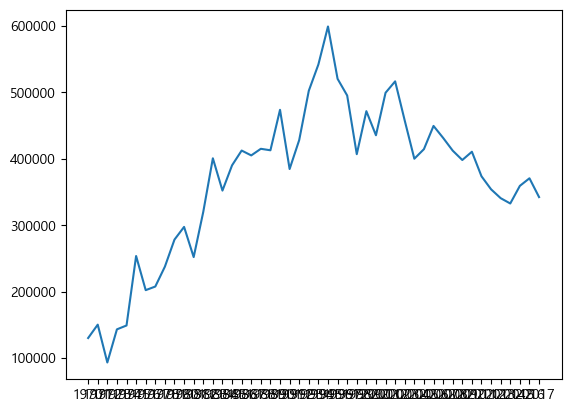

In [12]:
# x, y축 데이터를 plot 함수에 입력
plt.plot(sr_one.index, sr_one.values)

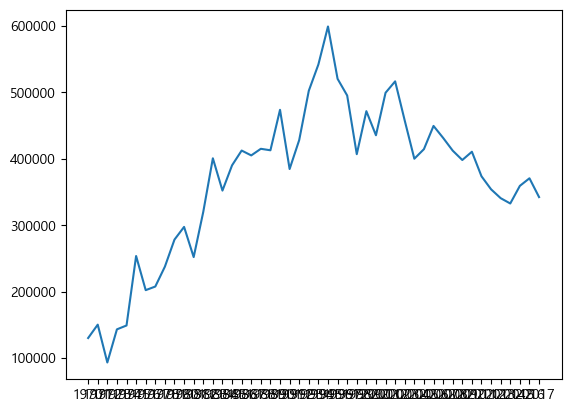

In [13]:
# 판다스 객체를 plot 함수에 입력
plt.plot(sr_one)
plt.show()

In [14]:
%pip install gdown

Note: you may need to restart the kernel to use updated packages.


In [15]:
# 구글 드라이브 공유시 데이터 조회방법
import gdown

import gdown

file_id = '1oxUlhFbbJqUEdAZnynTJUav5mCkM9sb7'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'cerdit.csv'

gdown.download(url,output,quiet=False)
df = pd.read_csv(output)
df.head()

# installments 할부개월수
# days_of_week 월요일 0 일요일 6
# holyday 1이면 공휴일 0이면 공휴일이 아님

Downloading...
From (original): https://drive.google.com/uc?id=1oxUlhFbbJqUEdAZnynTJUav5mCkM9sb7
From (redirected): https://drive.google.com/uc?id=1oxUlhFbbJqUEdAZnynTJUav5mCkM9sb7&confirm=t&uuid=cd243285-aaf6-40fc-ae5e-7d580721c8ad
To: c:\김지은\파이썬_src\pandas-data-analysis\part4\cerdit.csv
100%|██████████| 150M/150M [00:06<00:00, 24.2MB/s] 


,store_id,date,time,card_id,amount,installments,days_of_week,holyday
0,0,2016-12-14,18:05:31,d297bba73f,5,NaN,2,0
1,0,2016-12-14,18:05:54,d297bba73f,-5,NaN,2,0
2,0,2016-12-19,12:42:31,0880849c05,144,NaN,0,0
3,0,2016-12-19,12:48:08,8b4f9e0e95,66,NaN,0,0
4,0,2016-12-19,13:31:08,7ad237eed0,24,NaN,0,0


In [16]:
df['date'].dtype

dtype('O')

In [17]:
# 데이터가 날짜 인데.. 문자열 형태 즉 object이면
# datetime 으로 형식을 변경해서 년 월 일을 분리할 수 있다.
df['datetime'] = pd.to_datetime(df['date'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df.head()

,store_id,date,time,card_id,amount,installments,days_of_week,holyday,datetime,year,month
0,0,2016-12-14,18:05:31,d297bba73f,5,NaN,2,0,2016-12-14,2016,12
1,0,2016-12-14,18:05:54,d297bba73f,-5,NaN,2,0,2016-12-14,2016,12
2,0,2016-12-19,12:42:31,0880849c05,144,NaN,0,0,2016-12-19,2016,12
3,0,2016-12-19,12:48:08,8b4f9e0e95,66,NaN,0,0,2016-12-19,2016,12
4,0,2016-12-19,13:31:08,7ad237eed0,24,NaN,0,0,2016-12-19,2016,12


In [18]:
# 년도별 신용카드 매출액을 구해서 출력
# 시각화 plot x 축의 시간정보는 오름차수능로 정렬되었는 지 확인

In [ ]:

# 년도별 신용카드 매출액을 구해서 출력
year_amount = df.groupby("year")["amount"].sum()
print(year_amount)

year
2016     69385560
2017    238703895
2018    182751998
Name: amount, dtype: int64


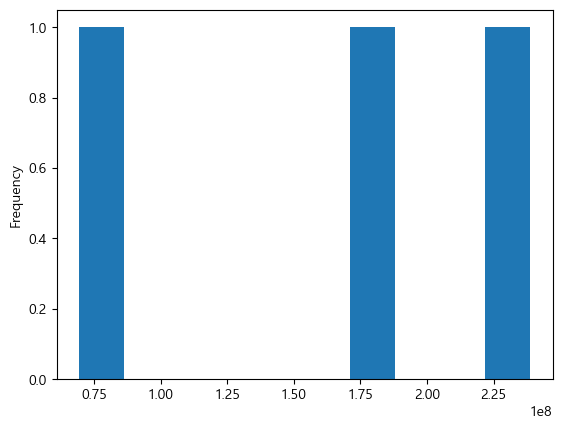

In [ ]:
# 시각화 plot x 축의 시간정보는 오름차수능로 정렬되었는 지 확인
ax = year_amount.plot()
# 읽기 쉽게 정리하기

In [ ]:
# 2017월별 신용카드 사용액
amount_2017_month = df[df['year'] == 2017].groupby("month")["amount"].sum()